<a href="https://www.kaggle.com/code/lalit7881/black-friday-sales-dataset-eda?scriptVersionId=321743183" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/noopurbhatt/retail-black-friday-sales-dataset/retail_black_friday_sales_100k.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/noopurbhatt/retail-black-friday-sales-dataset/retail_black_friday_sales_100k.csv")

In [3]:
df.head()

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35,99.92,1,99.92,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40,138.03,1,138.03,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25,131.00,1,131.00,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40,239.77,1,239.77,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30,84.61,2,169.22,Debit Card,2025-11-25,2,0,0


In [4]:
df.tail()

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
99995,T0099996,C025888,46-55,Other,Atlanta,New,P1702,Sports,462.86,25,347.14,2,694.28,Gift Card,2025-11-28,0,0,1
99996,T0099997,C028276,56+,Male,Houston,Returning,P3742,Beauty,87.86,15,74.68,2,149.36,Credit Card,2025-11-26,0,0,0
99997,T0099998,C025960,46-55,Other,Phoenix,VIP,P2100,Electronics,1930.61,40,1158.37,1,1158.37,Credit Card,2025-11-30,0,1,0
99998,T0099999,C005656,46-55,Other,Miami,New,P7444,Beauty,156.74,25,117.56,1,117.56,Gift Card,2025-11-30,6,1,0
99999,T0100000,C011624,56+,Other,Chicago,Returning,P9503,Electronics,1500.96,25,1125.72,1,1125.72,Gift Card,2025-11-27,3,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   customer_id       100000 non-null  object 
 2   age_group         100000 non-null  object 
 3   gender            100000 non-null  object 
 4   city              100000 non-null  object 
 5   customer_segment  100000 non-null  object 
 6   product_id        100000 non-null  object 
 7   product_category  100000 non-null  object 
 8   original_price    100000 non-null  float64
 9   discount_pct      100000 non-null  int64  
 10  final_price       100000 non-null  float64
 11  quantity          100000 non-null  int64  
 12  purchase_amount   100000 non-null  float64
 13  payment_method    100000 non-null  object 
 14  purchase_date     100000 non-null  object 
 15  purchase_hour     100000 non-null  int64  
 16  is_weekend        100

In [6]:
df.describe()

,original_price,discount_pct,final_price,quantity,purchase_amount,purchase_hour,is_weekend,is_black_friday
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,330.281911,26.631150,242.220661,1.447290,351.256307,11.482240,0.248110,0.126330
std,444.315916,12.249229,332.677331,0.815762,589.856777,6.912777,0.431918,0.332223
min,5.000000,5.000000,2.070000,1.000000,2.220000,0.000000,0.000000,0.000000
25%,88.117500,20.000000,62.940000,1.000000,75.750000,5.000000,0.000000,0.000000
50%,180.220000,25.000000,129.490000,1.000000,161.150000,11.000000,0.000000,0.000000
75%,333.712500,35.000000,247.575000,2.000000,358.722500,17.000000,0.000000,0.000000
max,2499.890000,60.000000,2374.900000,5.000000,11441.800000,23.000000,1.000000,1.000000


In [7]:
df.isnull()

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

transaction_id      0
customer_id         0
age_group           0
gender              0
city                0
customer_segment    0
product_id          0
product_category    0
original_price      0
discount_pct        0
final_price         0
quantity            0
purchase_amount     0
payment_method      0
purchase_date       0
purchase_hour       0
is_weekend          0
is_black_friday     0
dtype: int64

In [9]:
df.dtypes

transaction_id       object
customer_id          object
age_group            object
gender               object
city                 object
customer_segment     object
product_id           object
product_category     object
original_price      float64
discount_pct          int64
final_price         float64
quantity              int64
purchase_amount     float64
payment_method       object
purchase_date        object
purchase_hour         int64
is_weekend            int64
is_black_friday       int64
dtype: object

In [10]:
df.shape

(100000, 18)

In [11]:
df.columns

Index(['transaction_id', 'customer_id', 'age_group', 'gender', 'city',
       'customer_segment', 'product_id', 'product_category', 'original_price',
       'discount_pct', 'final_price', 'quantity', 'purchase_amount',
       'payment_method', 'purchase_date', 'purchase_hour', 'is_weekend',
       'is_black_friday'],
      dtype='object')

In [12]:
df.nunique()

transaction_id      100000
customer_id          32997
age_group                5
gender                   3
city                    10
customer_segment         4
product_id            9000
product_category        10
original_price       50252
discount_pct            10
final_price          43350
quantity                 5
purchase_amount      49554
payment_method           6
purchase_date            8
purchase_hour           24
is_weekend               2
is_black_friday          2
dtype: int64

## EDA

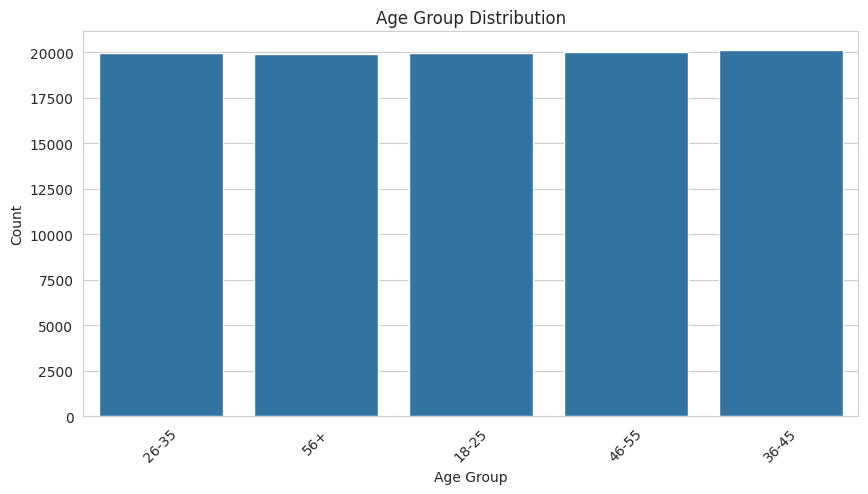

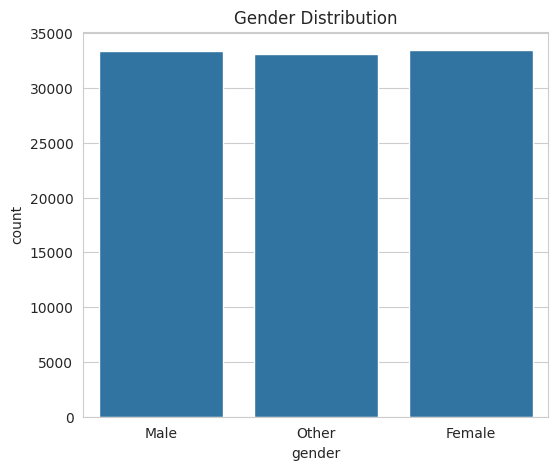

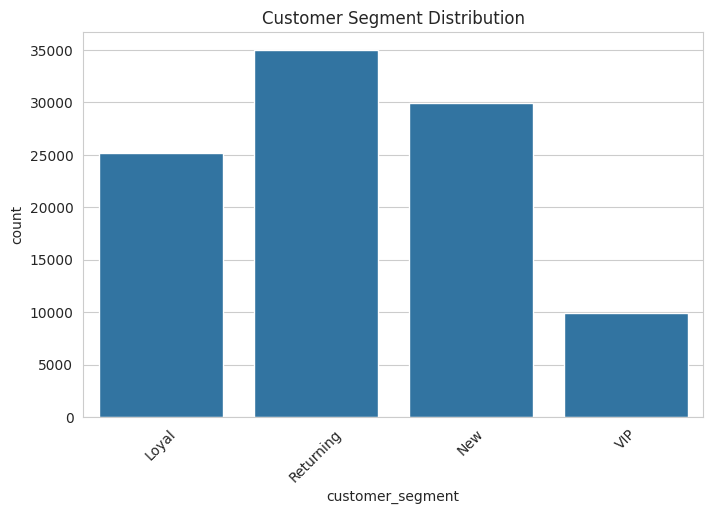

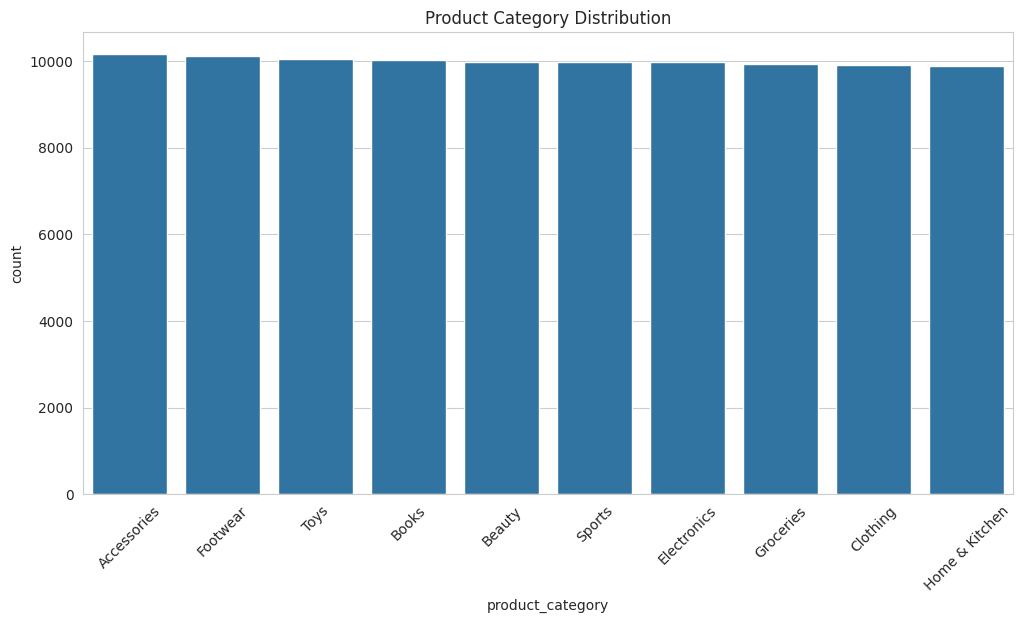

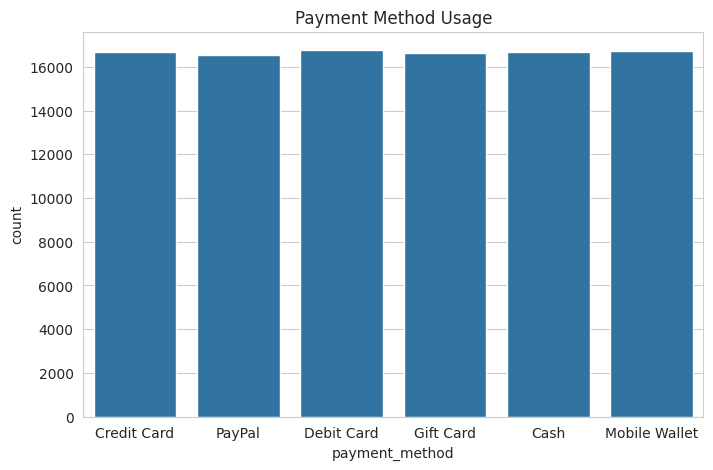

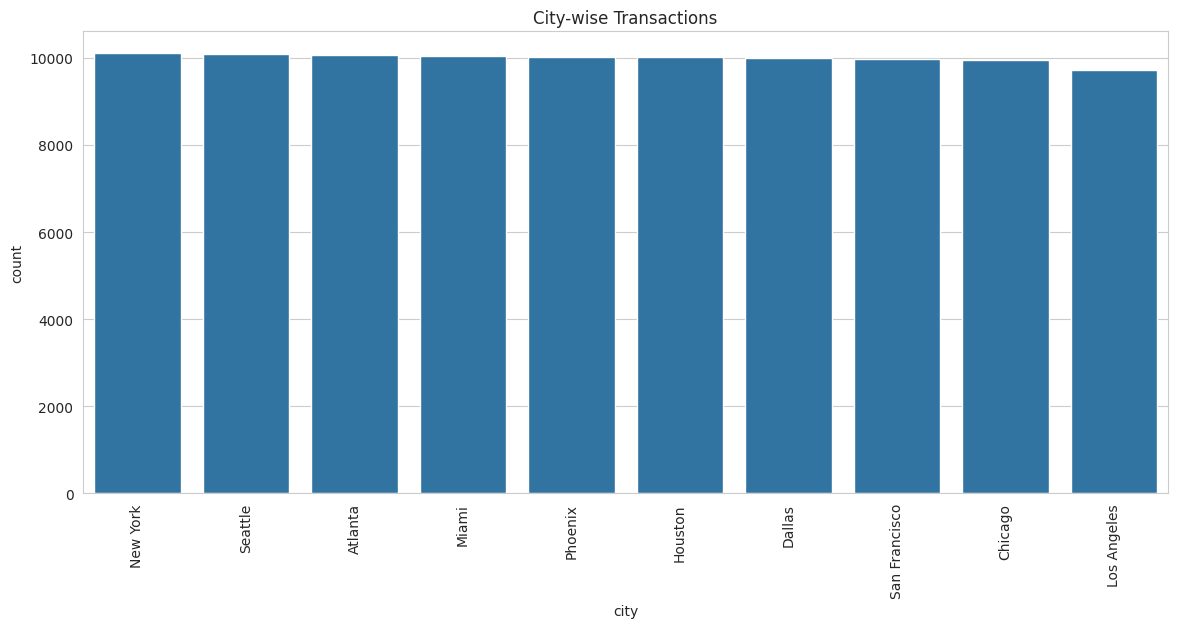

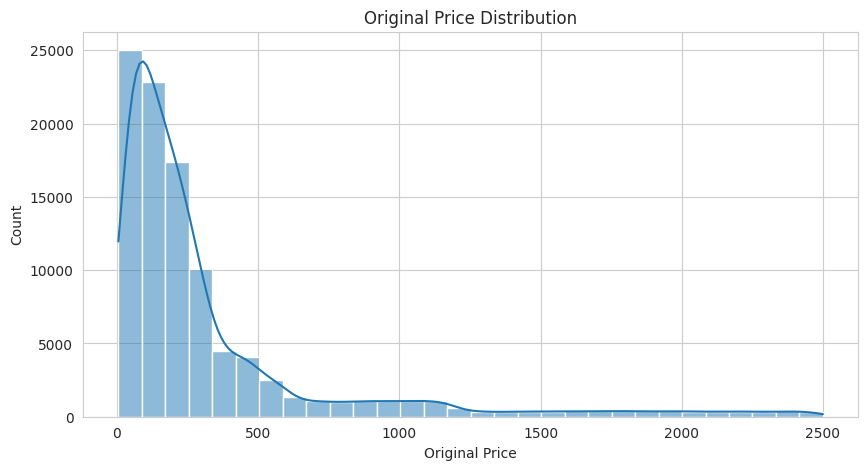

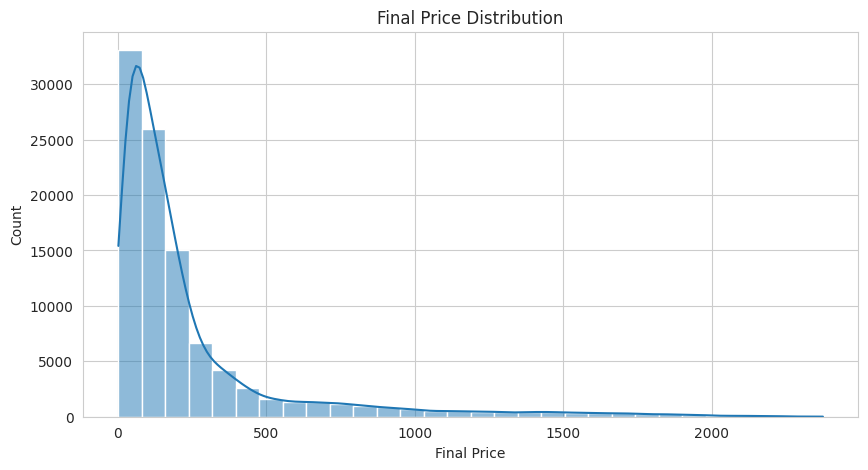

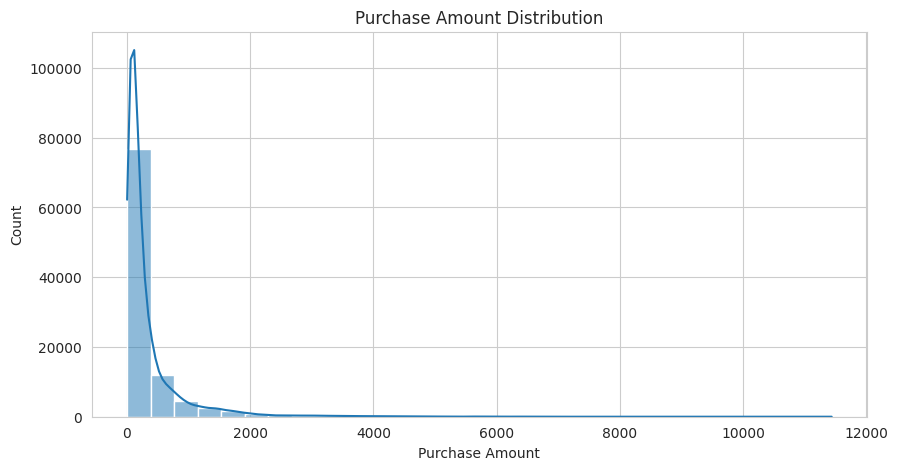

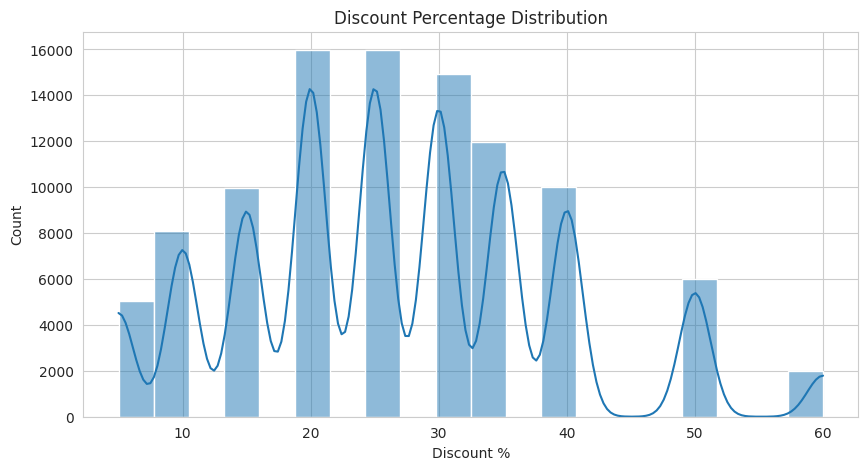

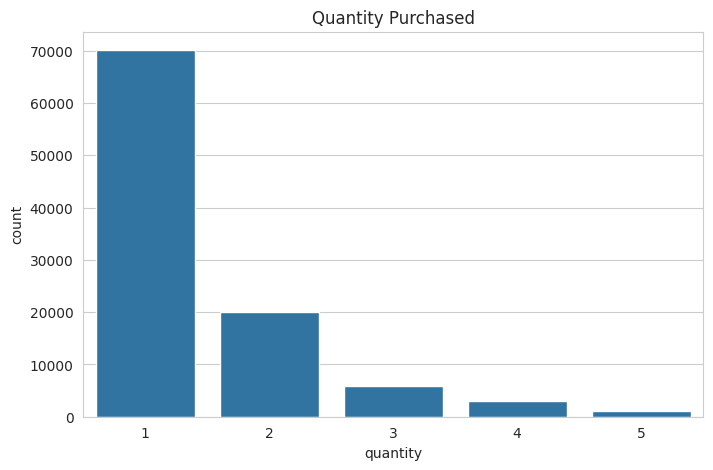

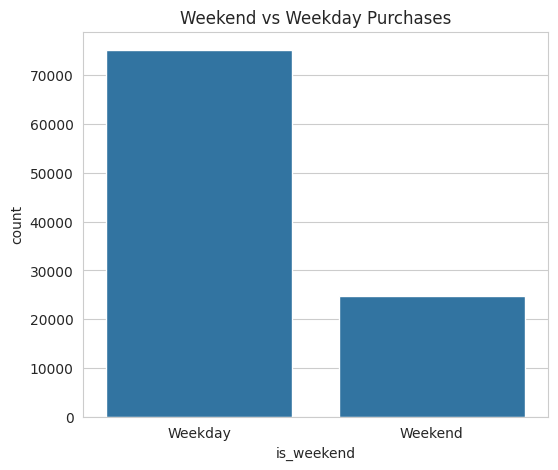

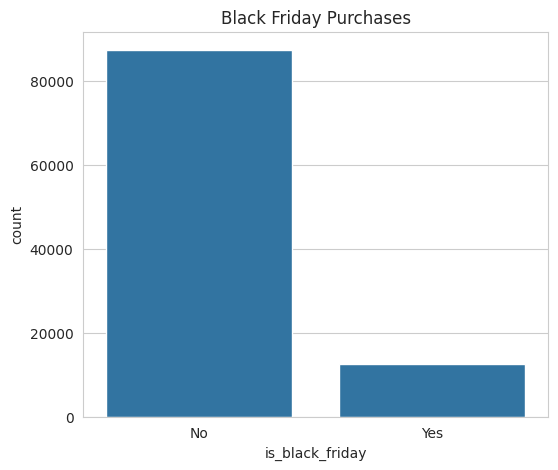

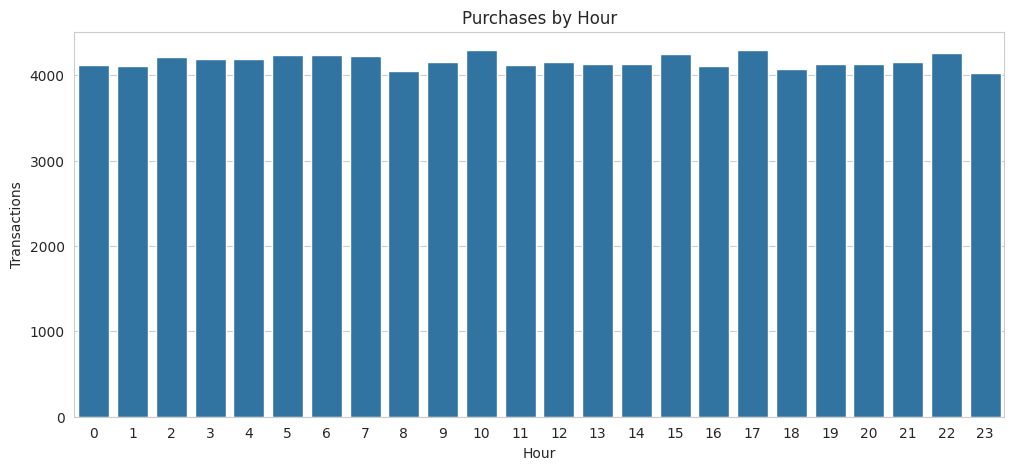

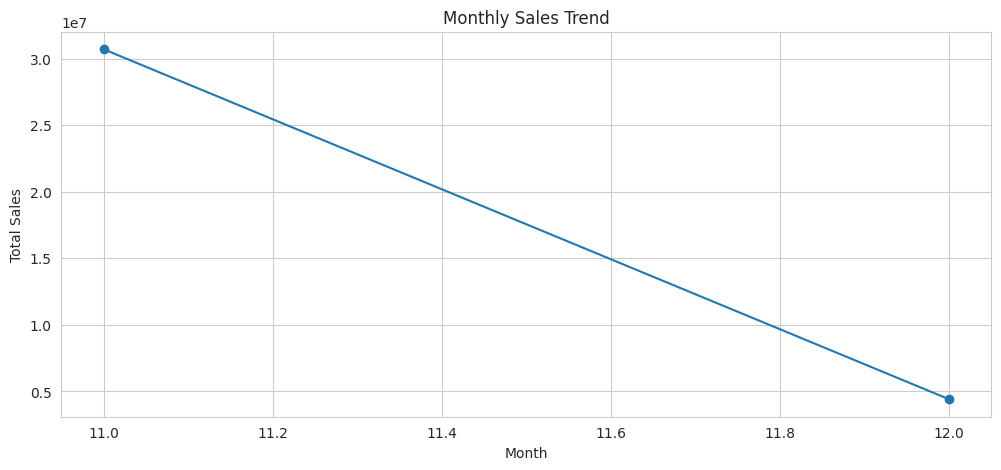

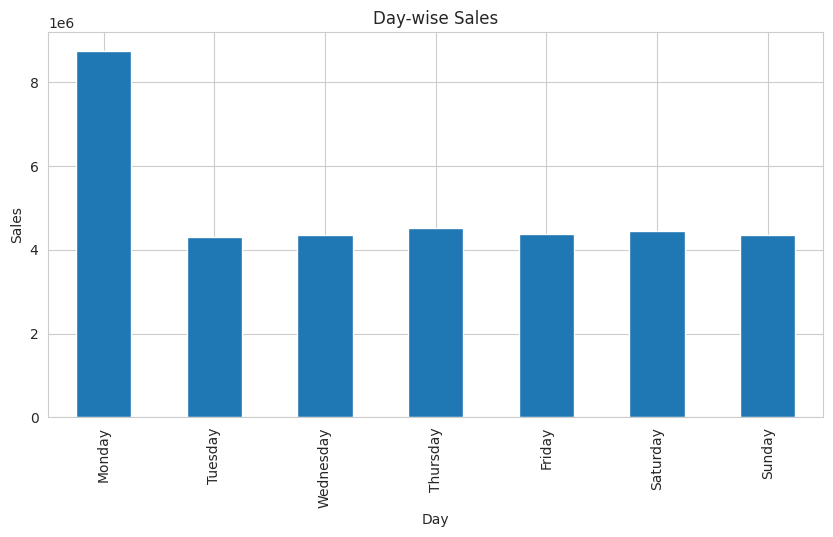

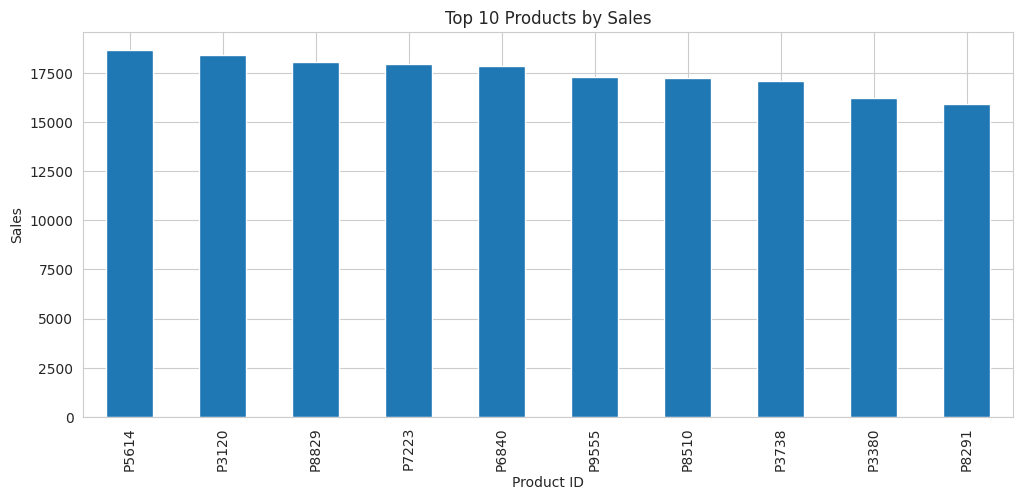

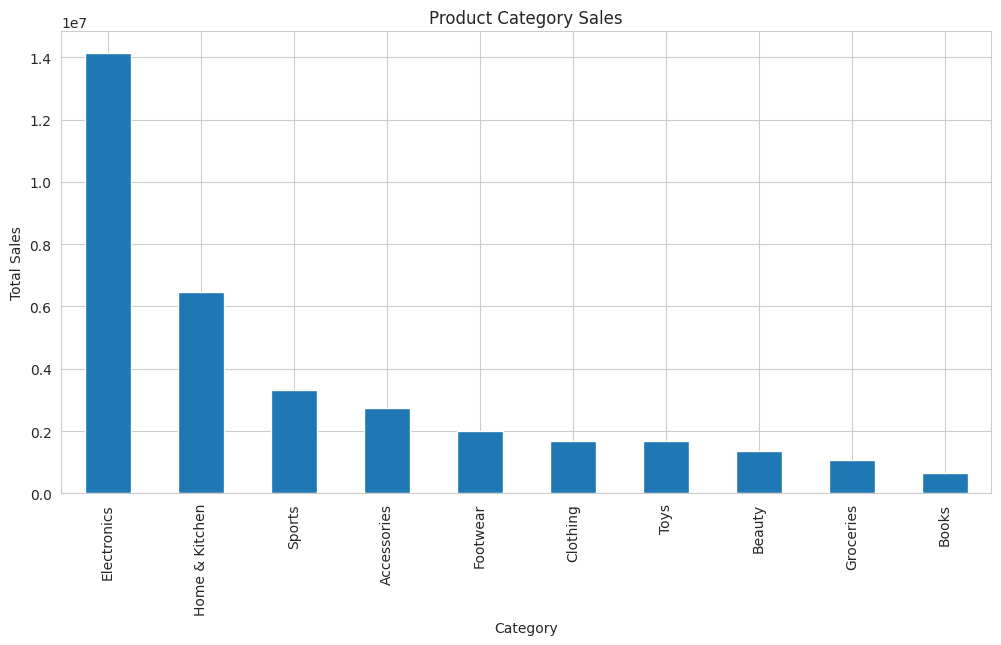

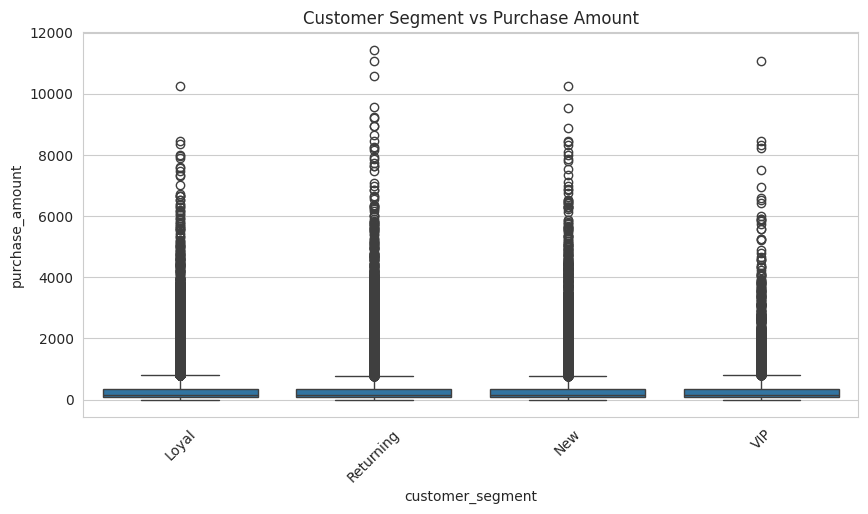

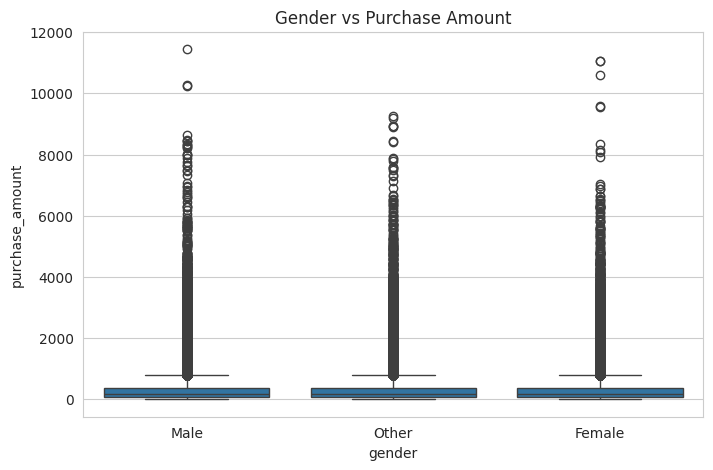

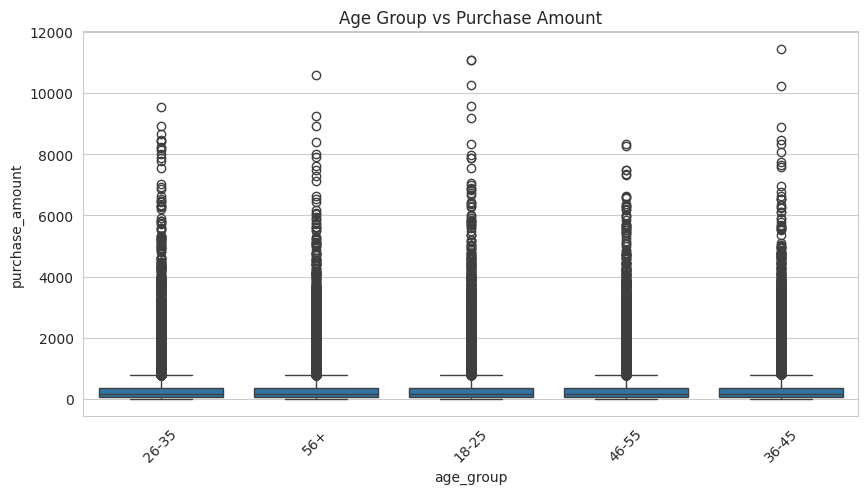

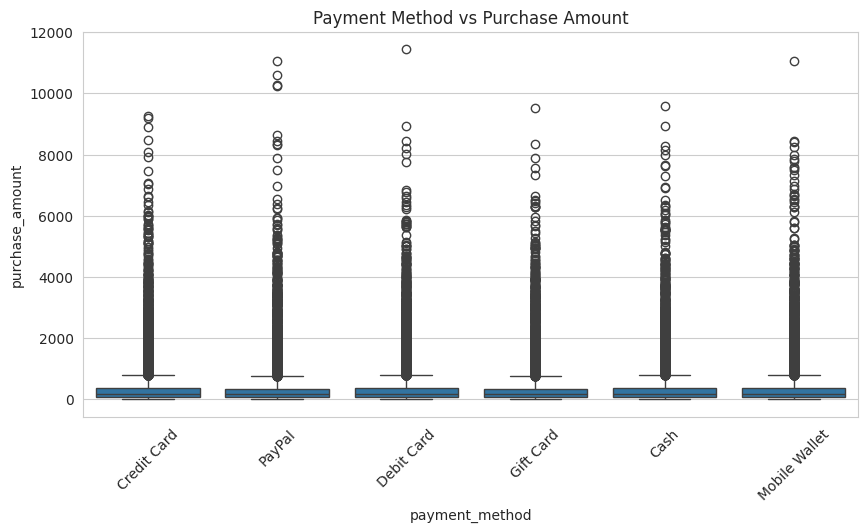

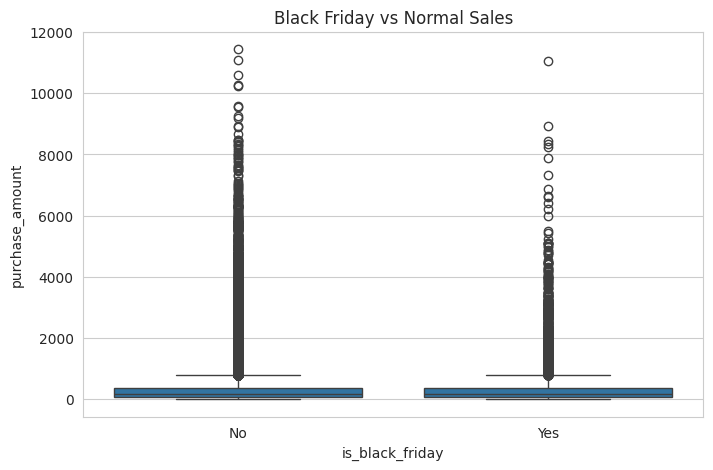

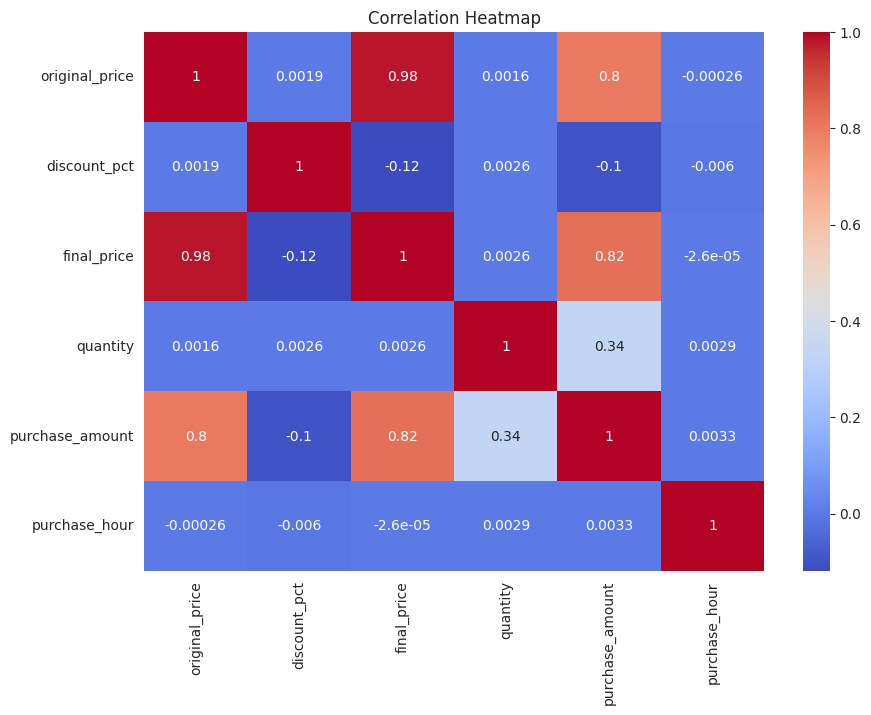

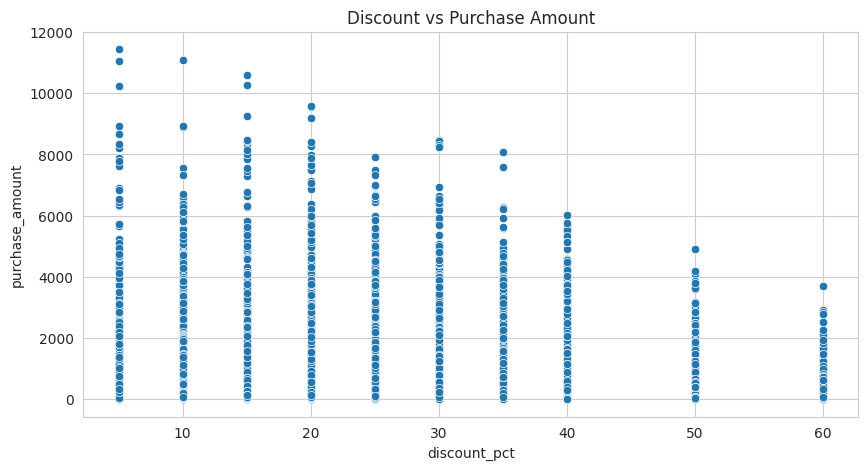

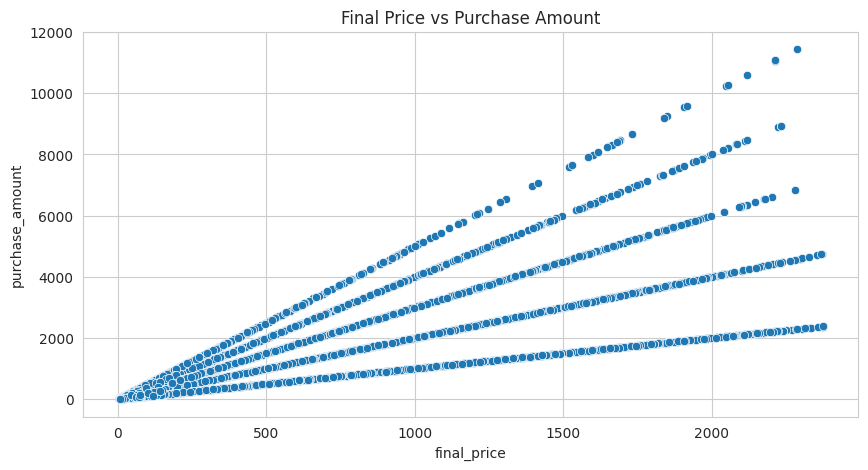

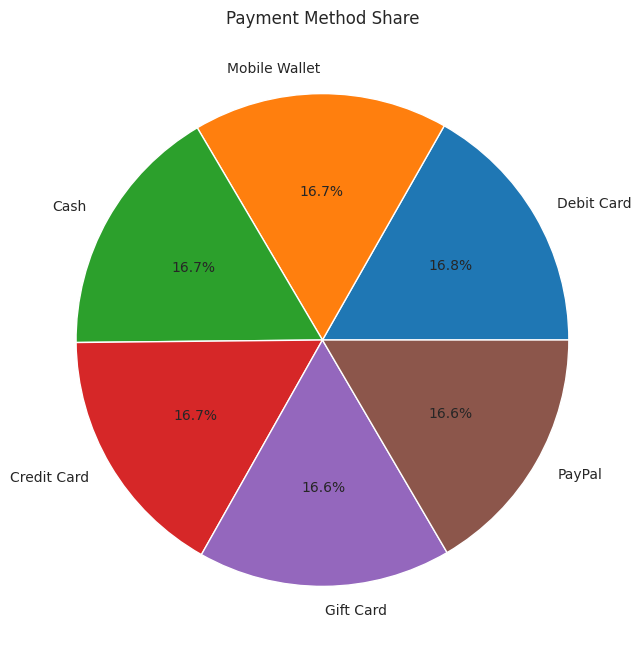

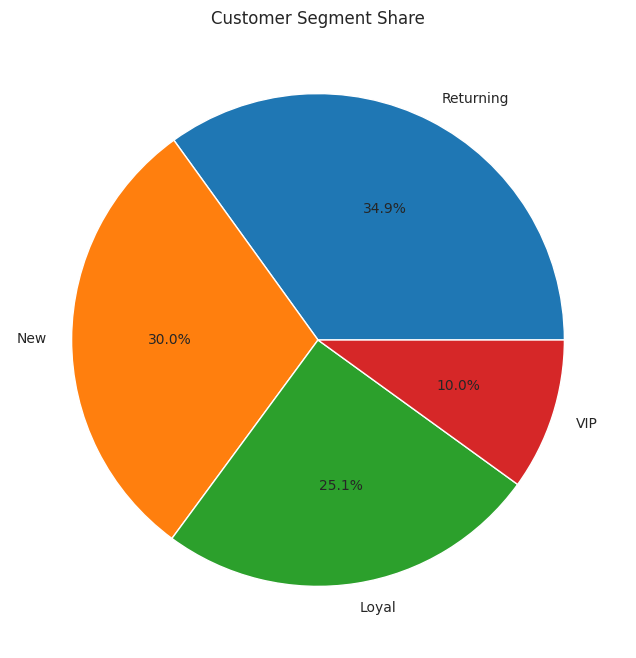

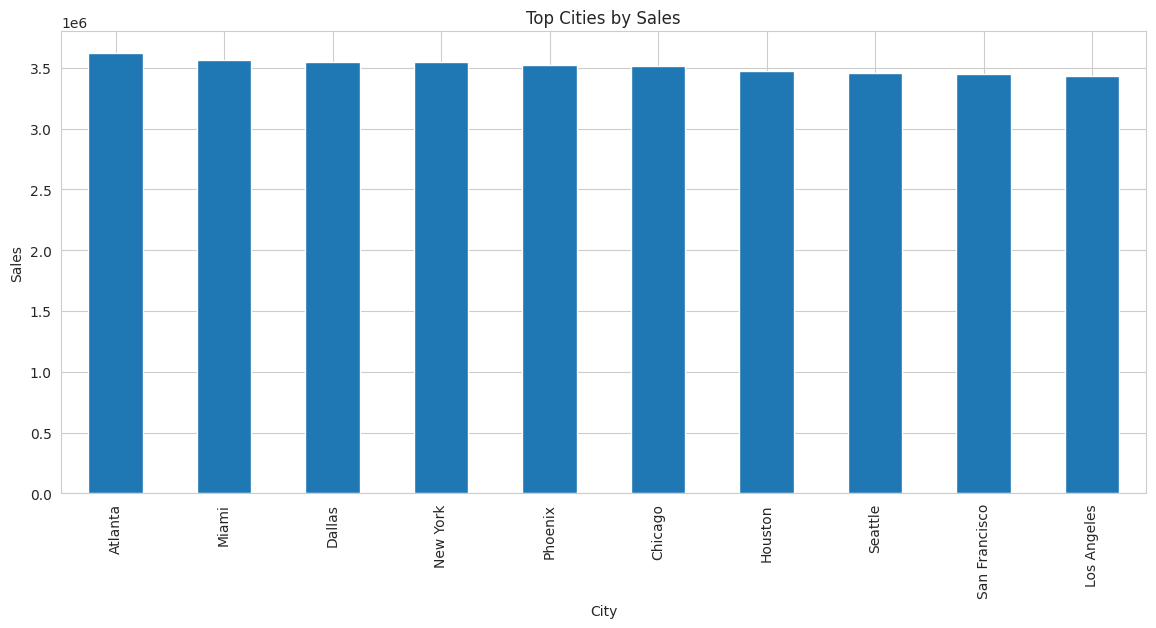

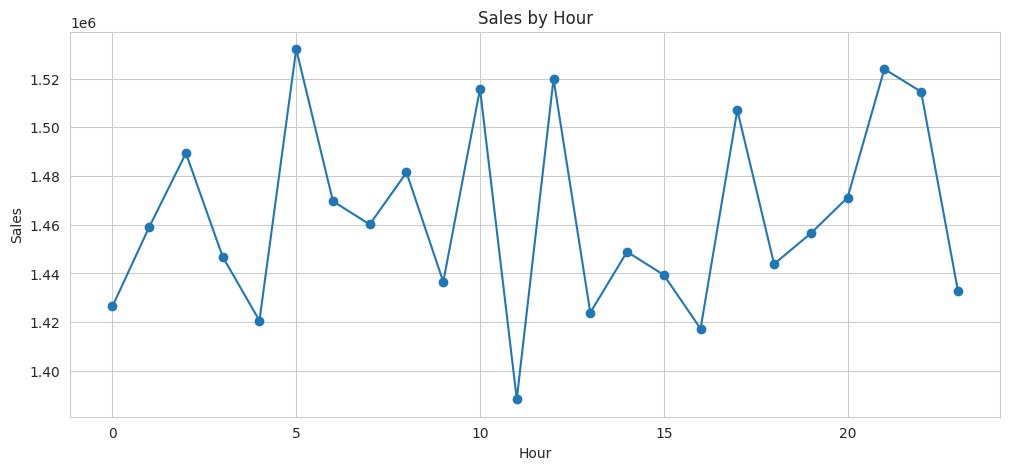

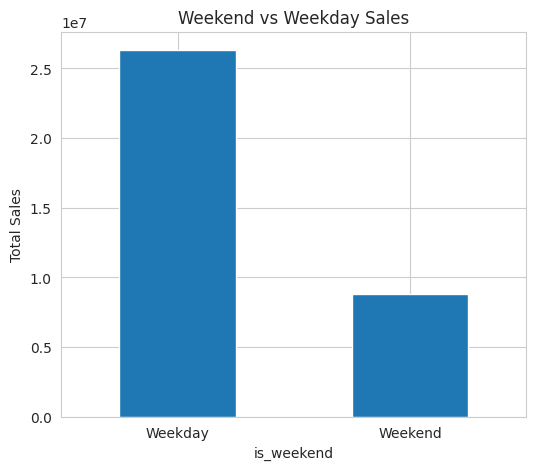

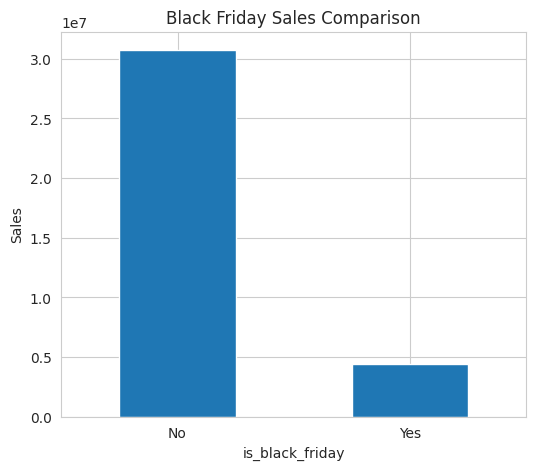

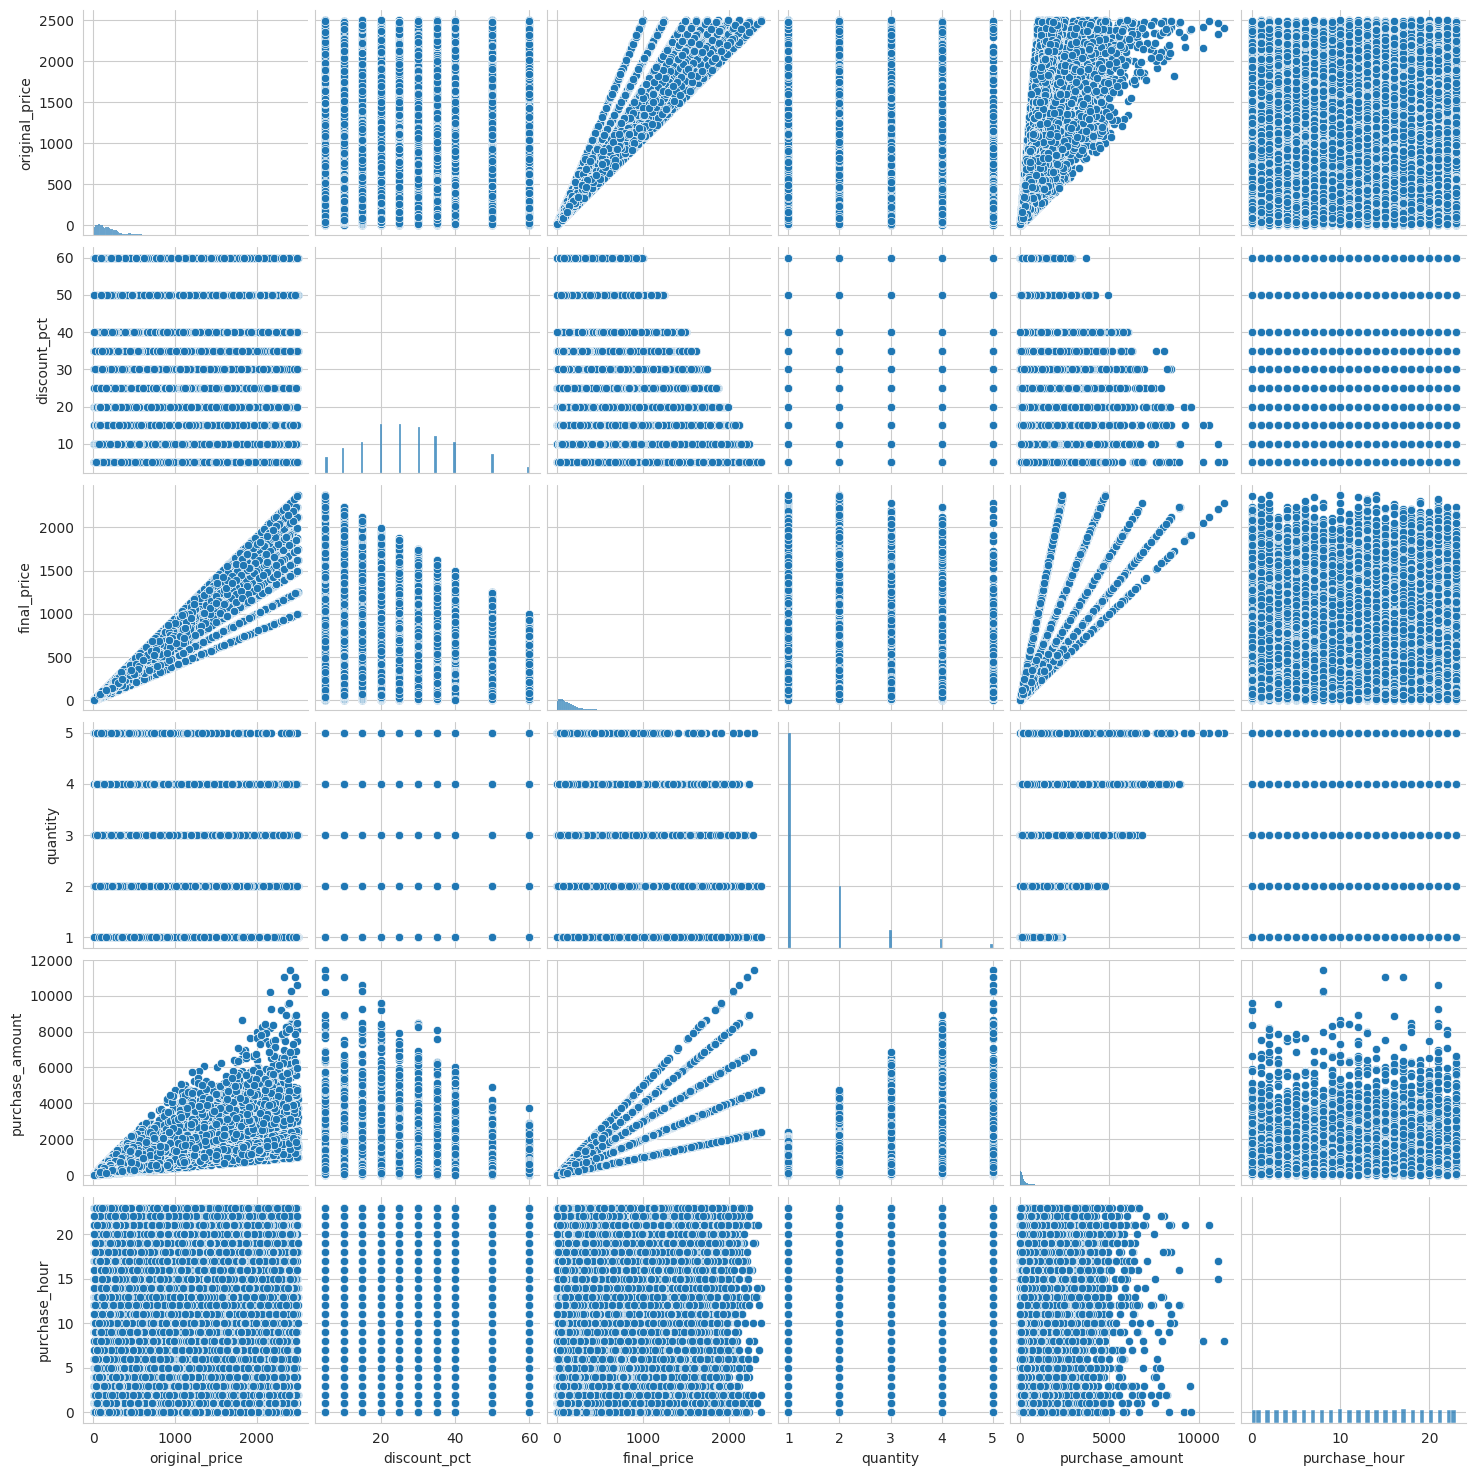

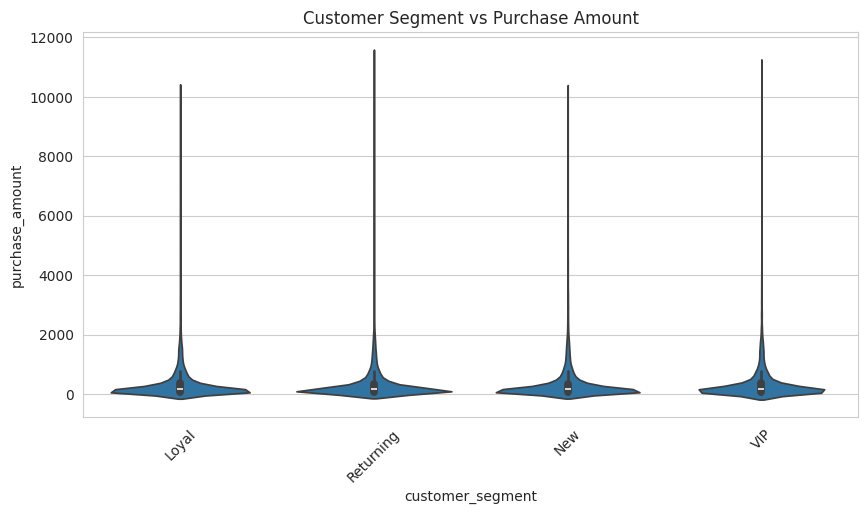

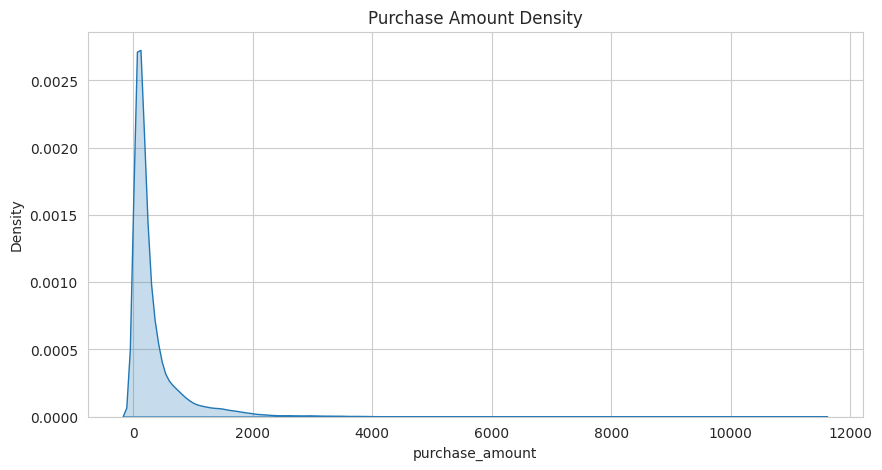


Visualization Completed Successfully!


In [13]:
# --------------------------------
# CONVERT DATE COLUMN
# --------------------------------
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Extract more date features
df['year'] = df['purchase_date'].dt.year
df['month'] = df['purchase_date'].dt.month
df['day'] = df['purchase_date'].dt.day
df['day_name'] = df['purchase_date'].dt.day_name()

# --------------------------------
# STYLE
# --------------------------------
sns.set_style("whitegrid")

# ==========================================
# 1. AGE GROUP DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='age_group')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 2. GENDER DISTRIBUTION
# ==========================================
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

# ==========================================
# 3. CUSTOMER SEGMENT DISTRIBUTION
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='customer_segment')
plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 4. PRODUCT CATEGORY DISTRIBUTION
# ==========================================
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='product_category',
    order=df['product_category'].value_counts().index
)
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 5. PAYMENT METHOD DISTRIBUTION
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='payment_method')
plt.title("Payment Method Usage")
plt.show()

# ==========================================
# 6. CITY-WISE TRANSACTIONS
# ==========================================
plt.figure(figsize=(14,6))
sns.countplot(
    data=df,
    x='city',
    order=df['city'].value_counts().index
)
plt.title("City-wise Transactions")
plt.xticks(rotation=90)
plt.show()

# ==========================================
# 7. ORIGINAL PRICE DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,5))
sns.histplot(df['original_price'], bins=30, kde=True)
plt.title("Original Price Distribution")
plt.xlabel("Original Price")
plt.show()

# ==========================================
# 8. FINAL PRICE DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,5))
sns.histplot(df['final_price'], bins=30, kde=True)
plt.title("Final Price Distribution")
plt.xlabel("Final Price")
plt.show()

# ==========================================
# 9. PURCHASE AMOUNT DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,5))
sns.histplot(df['purchase_amount'], bins=30, kde=True)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.show()

# ==========================================
# 10. DISCOUNT PERCENTAGE DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,5))
sns.histplot(df['discount_pct'], bins=20, kde=True)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.show()

# ==========================================
# 11. QUANTITY DISTRIBUTION
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quantity')
plt.title("Quantity Purchased")
plt.show()

# ==========================================
# 12. WEEKEND VS WEEKDAY SALES
# ==========================================
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='is_weekend')
plt.title("Weekend vs Weekday Purchases")
plt.xticks([0,1], ['Weekday','Weekend'])
plt.show()

# ==========================================
# 13. BLACK FRIDAY PURCHASES
# ==========================================
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='is_black_friday')
plt.title("Black Friday Purchases")
plt.xticks([0,1], ['No','Yes'])
plt.show()

# ==========================================
# 14. PURCHASE HOUR ANALYSIS
# ==========================================
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x='purchase_hour',
    order=sorted(df['purchase_hour'].unique())
)
plt.title("Purchases by Hour")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

# ==========================================
# 15. MONTHLY SALES TREND
# ==========================================
monthly_sales = df.groupby('month')['purchase_amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# ==========================================
# 16. DAY-WISE SALES ANALYSIS
# ==========================================
day_sales = df.groupby('day_name')['purchase_amount'].sum()

order = ['Monday','Tuesday','Wednesday',
         'Thursday','Friday','Saturday','Sunday']

day_sales = day_sales.reindex(order)

plt.figure(figsize=(10,5))
day_sales.plot(kind='bar')
plt.title("Day-wise Sales")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

# ==========================================
# 17. TOP 10 PRODUCTS BY SALES
# ==========================================
top_products = (
    df.groupby('product_id')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product ID")
plt.ylabel("Sales")
plt.show()

# ==========================================
# 18. TOP PRODUCT CATEGORIES BY SALES
# ==========================================
category_sales = (
    df.groupby('product_category')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
category_sales.plot(kind='bar')
plt.title("Product Category Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# ==========================================
# 19. CUSTOMER SEGMENT VS PURCHASE AMOUNT
# ==========================================
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='customer_segment',
    y='purchase_amount'
)
plt.title("Customer Segment vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 20. GENDER VS PURCHASE AMOUNT
# ==========================================
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='gender',
    y='purchase_amount'
)
plt.title("Gender vs Purchase Amount")
plt.show()

# ==========================================
# 21. AGE GROUP VS PURCHASE AMOUNT
# ==========================================
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='age_group',
    y='purchase_amount'
)
plt.title("Age Group vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 22. PAYMENT METHOD VS PURCHASE AMOUNT
# ==========================================
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='payment_method',
    y='purchase_amount'
)
plt.title("Payment Method vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 23. BLACK FRIDAY SALES COMPARISON
# ==========================================
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='is_black_friday',
    y='purchase_amount'
)
plt.title("Black Friday vs Normal Sales")
plt.xticks([0,1], ['No','Yes'])
plt.show()

# ==========================================
# 24. HEATMAP OF NUMERICAL FEATURES
# ==========================================
numerical_cols = [
    'original_price',
    'discount_pct',
    'final_price',
    'quantity',
    'purchase_amount',
    'purchase_hour'
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# 25. SCATTERPLOT - DISCOUNT VS PURCHASE
# ==========================================
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df,
    x='discount_pct',
    y='purchase_amount'
)
plt.title("Discount vs Purchase Amount")
plt.show()

# ==========================================
# 26. SCATTERPLOT - FINAL PRICE VS PURCHASE
# ==========================================
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df,
    x='final_price',
    y='purchase_amount'
)
plt.title("Final Price vs Purchase Amount")
plt.show()

# ==========================================
# 27. PIE CHART - PAYMENT METHODS
# ==========================================
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)
plt.title("Payment Method Share")
plt.show()

# ==========================================
# 28. PIE CHART - CUSTOMER SEGMENTS
# ==========================================
segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)
plt.title("Customer Segment Share")
plt.show()

# ==========================================
# 29. SALES BY CITY
# ==========================================
city_sales = (
    df.groupby('city')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))
city_sales.plot(kind='bar')
plt.title("Top Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

# ==========================================
# 30. SALES BY HOUR
# ==========================================
hour_sales = (
    df.groupby('purchase_hour')['purchase_amount']
    .sum()
)

plt.figure(figsize=(12,5))
hour_sales.plot(marker='o')
plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# ==========================================
# 31. WEEKEND SALES TREND
# ==========================================
weekend_sales = (
    df.groupby('is_weekend')['purchase_amount']
    .sum()
)

plt.figure(figsize=(6,5))
weekend_sales.plot(kind='bar')
plt.title("Weekend vs Weekday Sales")
plt.xticks([0,1], ['Weekday','Weekend'], rotation=0)
plt.ylabel("Total Sales")
plt.show()

# ==========================================
# 32. BLACK FRIDAY SALES TREND
# ==========================================
bf_sales = (
    df.groupby('is_black_friday')['purchase_amount']
    .sum()
)

plt.figure(figsize=(6,5))
bf_sales.plot(kind='bar')
plt.title("Black Friday Sales Comparison")
plt.xticks([0,1], ['No','Yes'], rotation=0)
plt.ylabel("Sales")
plt.show()

# ==========================================
# 33. PAIRPLOT
# ==========================================
sns.pairplot(df[numerical_cols])
plt.show()

# ==========================================
# 34. VIOLIN PLOT
# ==========================================
plt.figure(figsize=(10,5))
sns.violinplot(
    data=df,
    x='customer_segment',
    y='purchase_amount'
)
plt.title("Customer Segment vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 35. KDE PLOT
# ==========================================
plt.figure(figsize=(10,5))
sns.kdeplot(df['purchase_amount'], fill=True)
plt.title("Purchase Amount Density")
plt.show()

print("\nVisualization Completed Successfully!")

## Feature engineering

In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


Target Distribution:
is_black_friday
0    87367
1    12633
Name: count, dtype: int64

Categorical Columns:
['transaction_id', 'customer_id', 'age_group', 'gender', 'city', 'customer_segment', 'product_id', 'product_category', 'payment_method', 'day_name']

Numerical Columns:
['original_price', 'discount_pct', 'final_price', 'quantity', 'purchase_amount', 'purchase_hour', 'is_weekend']

Training Shape: (80000, 24)
Testing Shape: (20000, 24)


MODEL: Logistic Regression

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



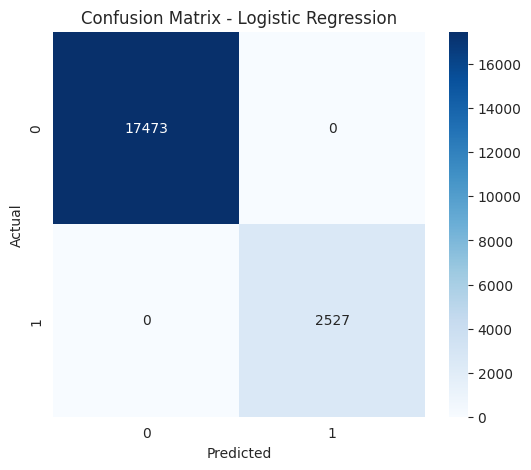

ROC AUC Score: 1.0000


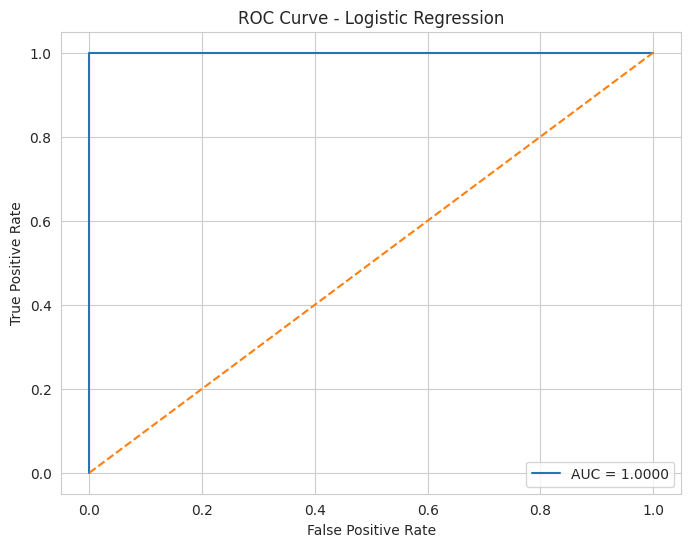



MODEL: Decision Tree

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



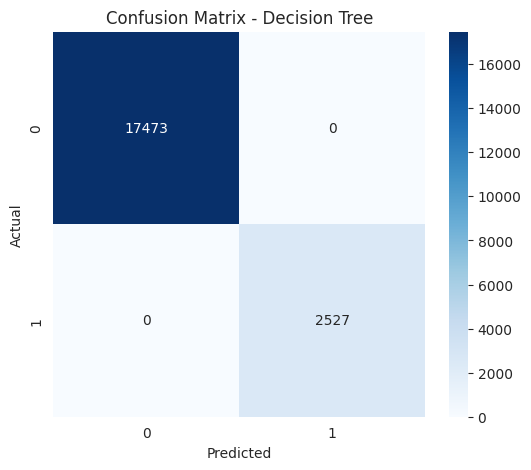

ROC AUC Score: 1.0000


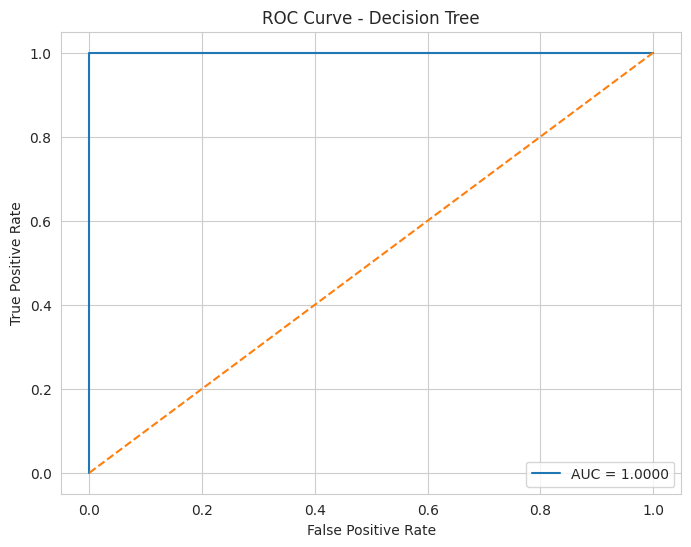



MODEL: Random Forest

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



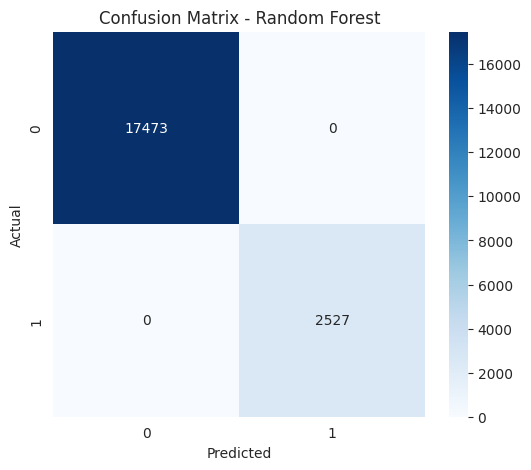

ROC AUC Score: 1.0000


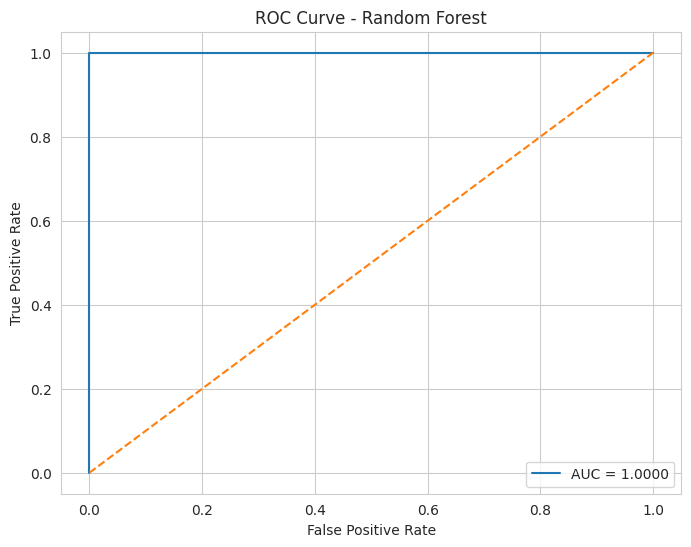



MODEL: Gradient Boosting

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



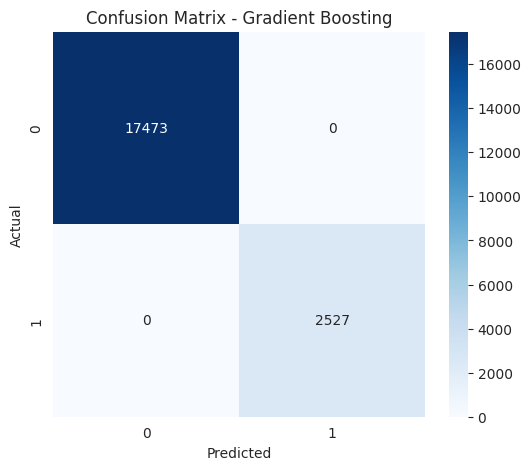

ROC AUC Score: 1.0000


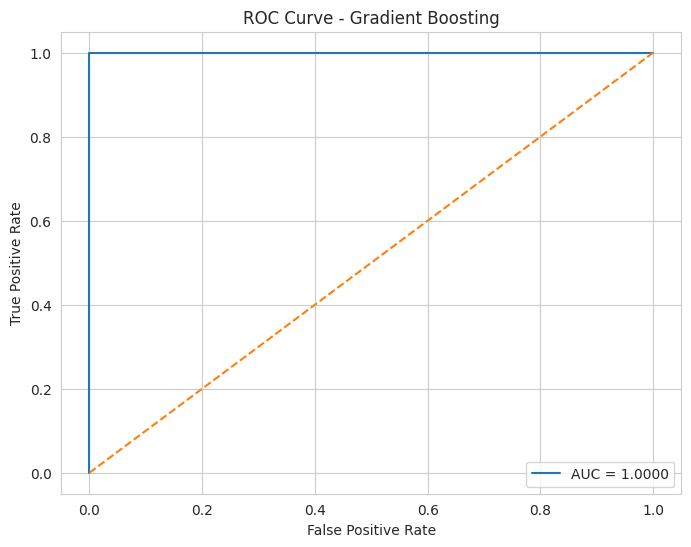



MODEL: AdaBoost

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



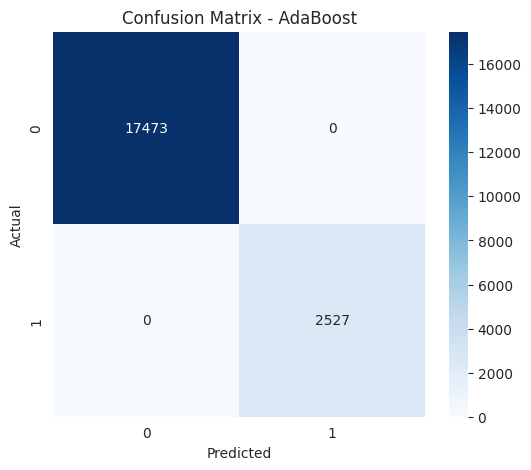

ROC AUC Score: 1.0000


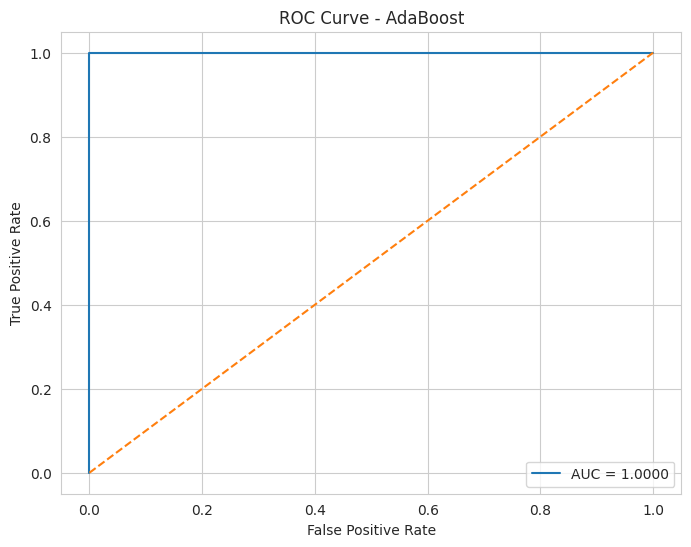



MODEL: Extra Trees

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



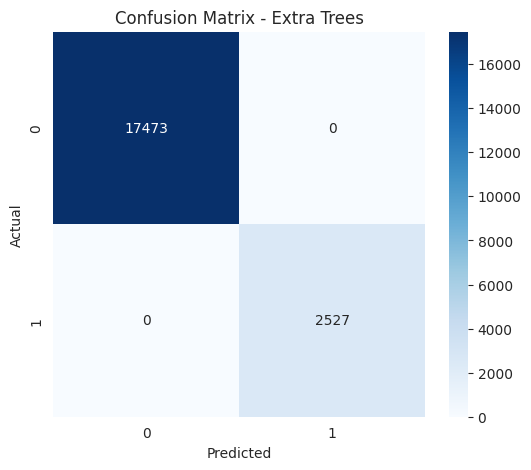

ROC AUC Score: 1.0000


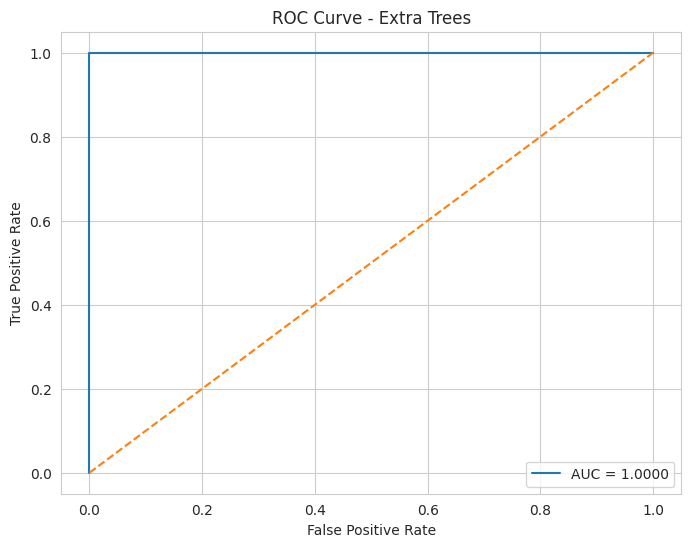



MODEL: KNN

Accuracy Score: 0.9877

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17473
           1       1.00      0.90      0.95      2527

    accuracy                           0.99     20000
   macro avg       0.99      0.95      0.97     20000
weighted avg       0.99      0.99      0.99     20000



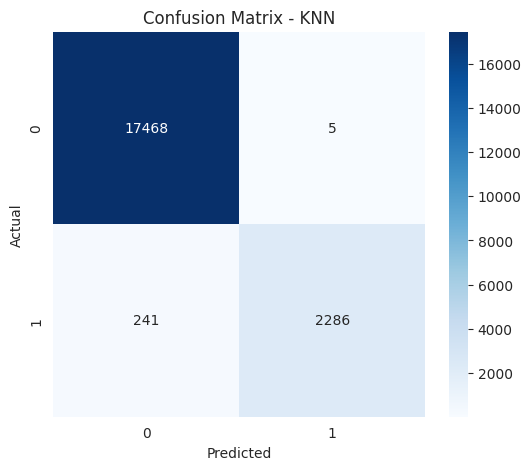

ROC AUC Score: 0.9977


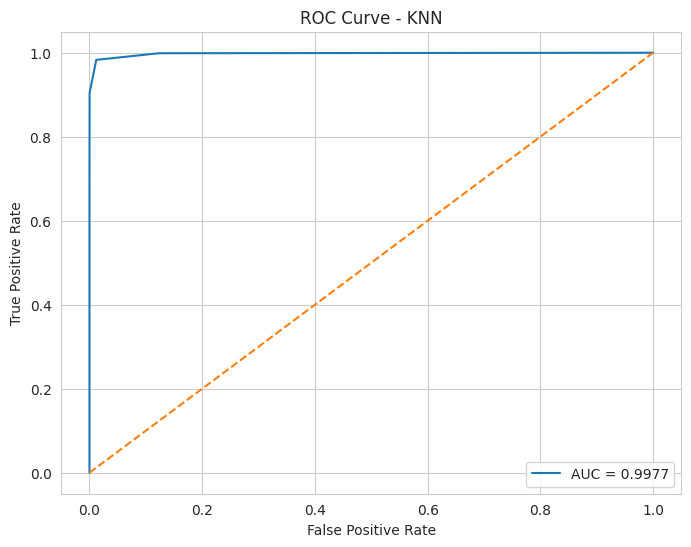



MODEL: SVM

Accuracy Score: 0.9999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17473
           1       1.00      1.00      1.00      2527

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



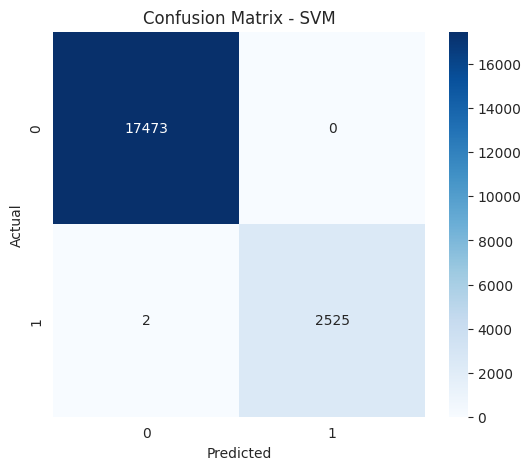

ROC AUC Score: 1.0000


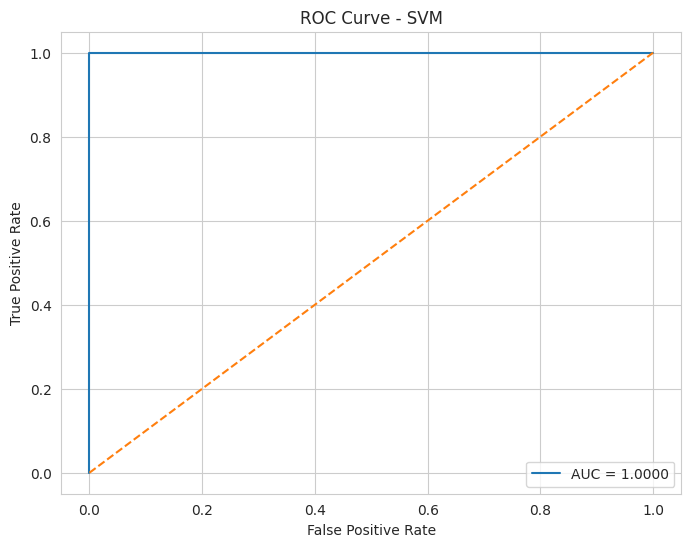



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
0  Logistic Regression    1.0000  1.000000
1        Decision Tree    1.0000  1.000000
2        Random Forest    1.0000  1.000000
3    Gradient Boosting    1.0000  1.000000
4             AdaBoost    1.0000  1.000000
5          Extra Trees    1.0000  1.000000
7                  SVM    0.9999  1.000000
6                  KNN    0.9877  0.997744


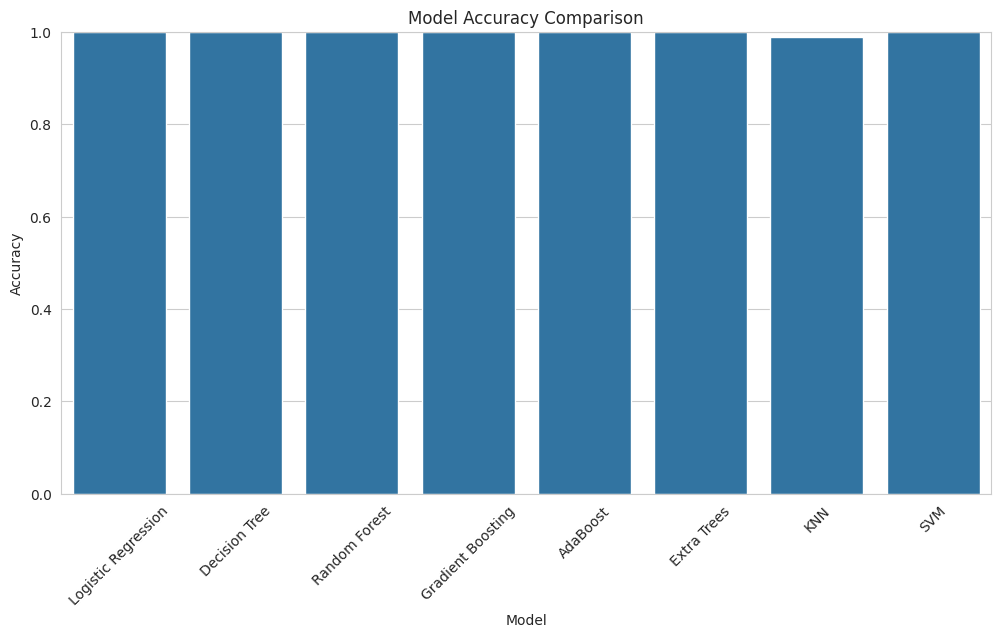

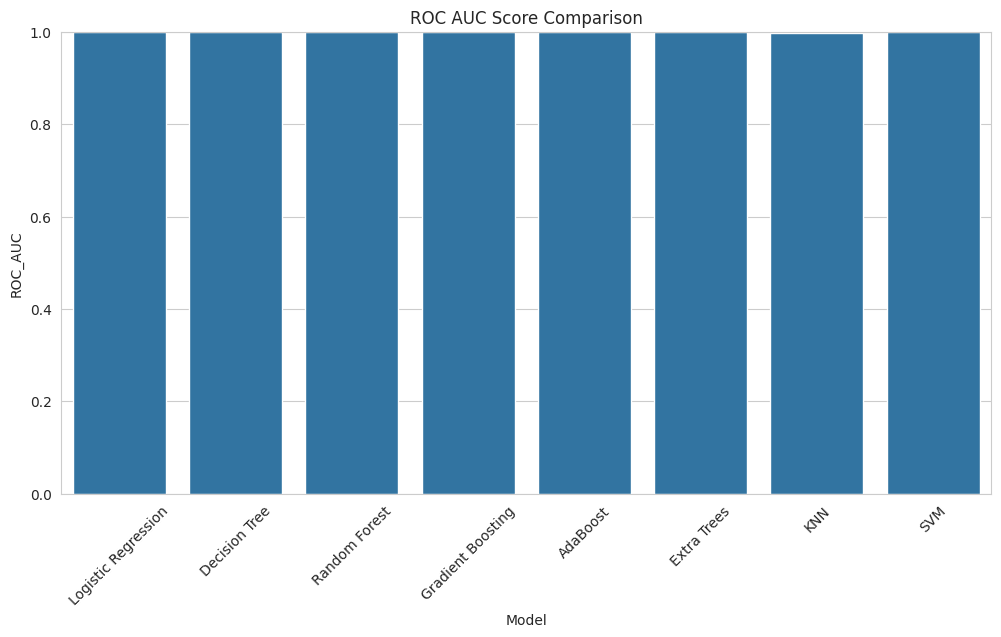



BEST MODEL
Best Model Name: Logistic Regression
Best Accuracy: 1.0
Best ROC AUC: 1.0

Top 20 Important Features:
                           Feature  Importance
120426             day_name_Friday    0.640178
120427             day_name_Monday    0.063758
120432          day_name_Wednesday    0.044738
6                       is_weekend    0.039431
120431            day_name_Tuesday    0.033076
120430           day_name_Thursday    0.031838
120428           day_name_Saturday    0.025189
120429             day_name_Sunday    0.012951
4                  purchase_amount    0.001058
2                      final_price    0.000979
0                   original_price    0.000944
5                    purchase_hour    0.000824
1                     discount_pct    0.000613
3                         quantity    0.000342
111395                 gender_Male    0.000286
111394               gender_Female    0.000247
111396                gender_Other    0.000245
111408        customer_segment_New    0

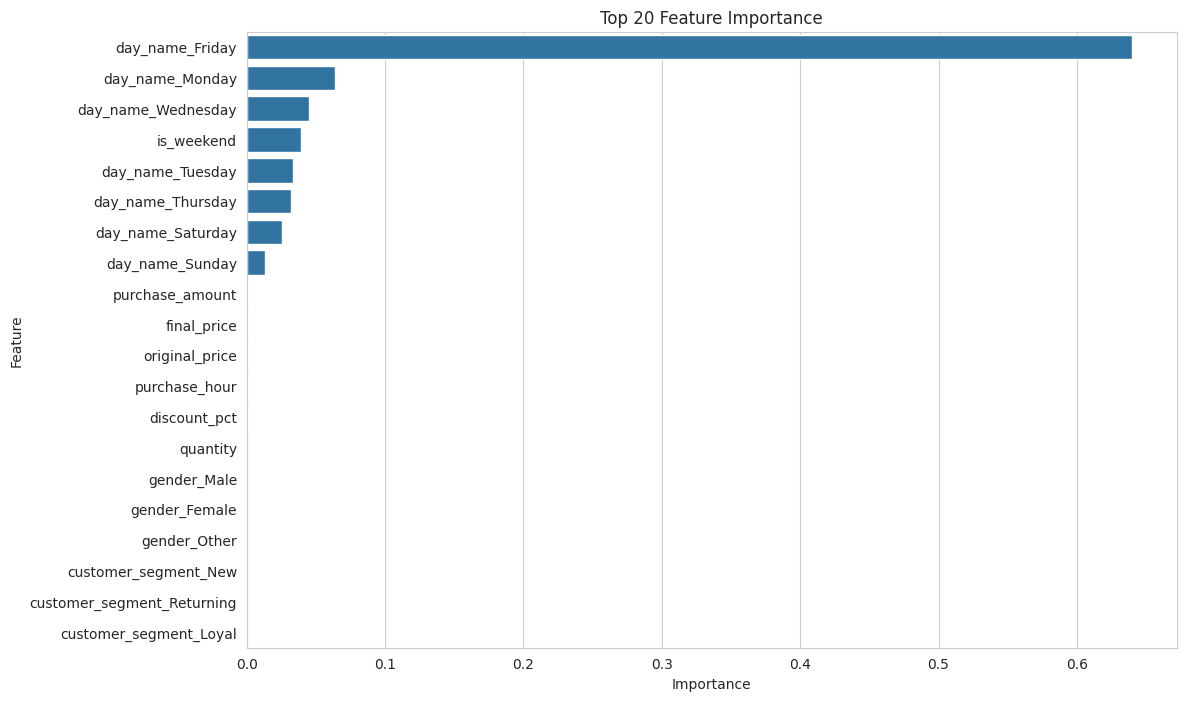


Model Results Saved Successfully!

Project Completed Successfully!


In [15]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Extract Date Features
df['purchase_year'] = df['purchase_date'].dt.year
df['purchase_month'] = df['purchase_date'].dt.month
df['purchase_day'] = df['purchase_date'].dt.day
df['purchase_dayofweek'] = df['purchase_date'].dt.dayofweek

# Drop original date column
df.drop('purchase_date', axis=1, inplace=True)

# =========================================================
# TARGET VARIABLE
# =========================================================
target = 'is_black_friday'

# Features and Target
X = df.drop(target, axis=1)
y = df[target]

print("\nTarget Distribution:")
print(y.value_counts())

# =========================================================
# IDENTIFY NUMERICAL & CATEGORICAL COLUMNS
# =========================================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Splitting BEFORE preprocessing avoids DATA LEAKAGE
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================================================
# PREPROCESSING PIPELINES
# =========================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    # Fill missing values
    ('imputer', SimpleImputer(strategy='median')),

    # Feature Scaling
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    # Fill missing values
    ('imputer', SimpleImputer(strategy='most_frequent')),

    # One Hot Encoding
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_cols),

    ('cat', categorical_transformer, categorical_cols)
])

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True)
}

# =========================================================
# STORE RESULTS
# =========================================================
results = []

# =========================================================
# TRAIN & EVALUATE MODELS
# =========================================================
for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL: {model_name}")
    print("="*70)

    # =====================================================
    # CREATE PIPELINE
    # =====================================================
    # Pipeline prevents data leakage
    # =====================================================

    clf = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)
    ])

    # =====================================================
    # TRAIN MODEL
    # =====================================================
    clf.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================
    y_pred = clf.predict(X_test)

    # Probability Predictions
    y_prob = clf.predict_proba(X_test)[:, 1]

    # =====================================================
    # ACCURACY
    # =====================================================
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score: {accuracy:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =====================================================
    # ROC AUC SCORE
    # =====================================================
    auc_score = roc_auc_score(y_test, y_prob)

    print(f"ROC AUC Score: {auc_score:.4f}")

    # =====================================================
    # ROC CURVE
    # =====================================================
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc_score:.4f}"
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend()

    plt.show()

    # =====================================================
    # SAVE RESULTS
    # =====================================================
    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score
    })

# =========================================================
# RESULTS COMPARISON
# =========================================================
results_df = pd.DataFrame(results)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df.sort_values(
    by='Accuracy',
    ascending=False
))

# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0,1)

plt.show()

# =========================================================
# VISUALIZE ROC AUC SCORE
# =========================================================
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC'
)

plt.title("ROC AUC Score Comparison")
plt.xticks(rotation=45)
plt.ylim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print("Best Model Name:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])
print("Best ROC AUC:", best_model['ROC_AUC'])

# =========================================================
# FEATURE IMPORTANCE
# Only for Tree Based Models
# =========================================================

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(random_state=42))
])

# Train
rf_pipeline.fit(X_train, y_train)

# =========================================================
# GET FEATURE NAMES
# =========================================================
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_['cat'][
    'encoder'
].get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

# =========================================================
# GET IMPORTANCE
# =========================================================
importance = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))

# =========================================================
# VISUALIZE FEATURE IMPORTANCE
# =========================================================
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance_df.head(20),
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Feature Importance")
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================
results_df.to_csv("model_results.csv", index=False)

print("\nModel Results Saved Successfully!")

print("\nProject Completed Successfully!")

## Thank you......pls upvote!!!!!!!!!!!